# Notebook 3 — Génération du Biais Inductif

**Objectif :** Fusionner les 8 métriques IQA du Notebook 2 en un **score unique $c \in [0, 1]$**  
interprétable par le cVAE (1 = très bonne qualité, 0 = image très dégradée).

**Trois méthodes disponibles** (sélectionnées via `APPROACH` dans `pipeline_config.py`) :

| Méthode | Principe | Avantage |
|---|---|---|
| **A — Score pondéré** | Combinaison linéaire des métriques normalisées | Interprétable physiquement |
| **B — PCA (PC1)** | Premier composant principal = direction de variance maximale | Objectif, pas de choix arbitraire de poids |
| **C — Hybride** | Moyenne de A + B + PCA ResNet-18 | Plus riche, exploite les features apprises |

**Livrable :** `outputs/labels_quality.csv` — pont vers le cVAE (Notebooks 4 & 5).

## 0. Configuration

In [1]:
from pathlib import Path
from pipeline_config import APPROACH, get_approach_config, get_score_column, use_resnet, print_approach_summary

# ── Approche sélectionnée ──
print_approach_summary()
USE_RESNET = use_resnet()

# Dossier de sortie pour ce notebook
OUTPUT_DIR = Path("outputs_theophile/03_Inductive_Bias_Generation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Entrées (produites par le Notebook 2)
NB02_DIR       = Path("outputs_theophile/02_IQA_Metrics_Extraction")
CSV_METRICS    = NB02_DIR / "patch_metrics_full.csv"
RESNET_NPY     = NB02_DIR / "resnet18_features.npy"
RESNET_IDS_CSV = NB02_DIR / "resnet18_ids.csv"
QMAPS_DIR      = NB02_DIR / "quality_maps"

# Sortie principale
OUT_LABELS_CSV = OUTPUT_DIR / "labels_quality.csv"

# Poids pour la Méthode A (somme = 1.0)
# Justification : tenengrad est la métrique la plus discriminante sur DSA
WEIGHTS = {
    "tenengrad":   0.30,
    "laplacian_var": 0.25,
    "rms_contrast": 0.15,
    "entropy_inv": 0.15,   # entropie inversée : haute entropie = mauvaise qualité
    "spatial_homogeneity": 0.10,  # feature engineerée (section 4)
    "directional_balance": 0.05,  # feature engineerée (section 4)
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

print(f"Entrée métriques : {CSV_METRICS}")
print(f"Sortie labels    : {OUT_LABELS_CSV}")

╔══════════════════════════════════════════════════════════╗
║  Approche : B — PCA (PC1)                                   ║
╚══════════════════════════════════════════════════════════╝
  Colonne de score : score_pca
  Premier composant principal normalisé [0,1], signe corrigé par corrélation avec Tenengrad. Objectif, data-driven.

Entrée métriques : outputs_theophile/02_IQA_Metrics_Extraction/patch_metrics_full.csv
Sortie labels    : outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")

/home/infres/nadiedjoa-24/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Imports OK


## 2. Chargement des métriques (sortie Notebook 2)

In [3]:
df_raw = pd.read_csv(CSV_METRICS)

# Identifier le split train/val à partir du chemin de l'image
# seg_train → "train", seg_val → "val"
def _get_split(path_str: str) -> str:
    if "seg_train" in str(path_str):
        return "train"
    elif "seg_val" in str(path_str):
        return "val"
    return "unknown"

df_raw["split"] = df_raw["path"].apply(_get_split)

print(f"Dataset chargé : {len(df_raw)} lignes, {len(df_raw.columns)} colonnes")
print(f"Split : {df_raw['split'].value_counts().to_dict()}")
print(f"Colonnes disponibles :\n{list(df_raw.columns)}")

Dataset chargé : 1200 lignes, 36 colonnes
Split : {'train': 1000, 'val': 200}
Colonnes disponibles :
['image_id', 'path', 'n_valid_patches', 'laplacian_var_mean', 'laplacian_var_std', 'laplacian_var_max', 'laplacian_var_min', 'rms_contrast_mean', 'rms_contrast_std', 'rms_contrast_max', 'rms_contrast_min', 'entropy_mean', 'entropy_std', 'entropy_max', 'entropy_min', 'tenengrad_mean', 'tenengrad_std', 'tenengrad_max', 'tenengrad_min', 'ten_H_mean', 'ten_H_std', 'ten_H_max', 'ten_H_min', 'ten_V_mean', 'ten_V_std', 'ten_V_max', 'ten_V_min', 'ten_D1_mean', 'ten_D1_std', 'ten_D1_max', 'ten_D1_min', 'ten_D2_mean', 'ten_D2_std', 'ten_D2_max', 'ten_D2_min', 'split']


## 3. Nettoyage et inspection

In [4]:
# Colonnes de métriques par suffixe
MEAN_COLS = [c for c in df_raw.columns if c.endswith("_mean")]
STD_COLS  = [c for c in df_raw.columns if c.endswith("_std")]
MAX_COLS  = [c for c in df_raw.columns if c.endswith("_max")]
MIN_COLS  = [c for c in df_raw.columns if c.endswith("_min")]

print(f"Métriques (_mean) : {MEAN_COLS}")
print(f"Métriques (_max)  : {MAX_COLS}")
print(f"Métriques (_min)  : {MIN_COLS}")
print()
print(df_raw[MEAN_COLS].isna().sum())

# Suppression des lignes avec erreurs de traitement
n_before = len(df_raw)
df = df_raw.dropna(subset=MEAN_COLS).copy().reset_index(drop=True)
print(f"\nImages conservées : {len(df)} / {n_before}  ({n_before - len(df)} supprimées)")

Métriques (_mean) : ['laplacian_var_mean', 'rms_contrast_mean', 'entropy_mean', 'tenengrad_mean', 'ten_H_mean', 'ten_V_mean', 'ten_D1_mean', 'ten_D2_mean']
Métriques (_max)  : ['laplacian_var_max', 'rms_contrast_max', 'entropy_max', 'tenengrad_max', 'ten_H_max', 'ten_V_max', 'ten_D1_max', 'ten_D2_max']
Métriques (_min)  : ['laplacian_var_min', 'rms_contrast_min', 'entropy_min', 'tenengrad_min', 'ten_H_min', 'ten_V_min', 'ten_D1_min', 'ten_D2_min']

laplacian_var_mean    0
rms_contrast_mean     0
entropy_mean          0
tenengrad_mean        0
ten_H_mean            0
ten_V_mean            0
ten_D1_mean           0
ten_D2_mean           0
dtype: int64

Images conservées : 1200 / 1200  (0 supprimées)


In [5]:
# Inspection des outliers (> 3σ)
print("Outliers (> 3σ) par métrique :")
for col in MEAN_COLS + MAX_COLS + MIN_COLS:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    n_out = (z > 3).sum()
    if n_out > 0:
        print(f"  {col:30s} → {n_out} outliers")

# On garde les outliers : ils représentent les images vraiment dégradées
# que l'on veut distinguer. On les clippe à 1er/99e percentile pour
# ne pas perturber la normalisation Min-Max.
# ⚠ Anti-leakage : percentiles calculés uniquement sur TRAIN
df_clipped = df.copy()
train_mask = df["split"] == "train"
for col in MEAN_COLS + MAX_COLS + MIN_COLS:
    lo, hi = df.loc[train_mask, col].quantile(0.01), df.loc[train_mask, col].quantile(0.99)
    df_clipped[col] = df[col].clip(lo, hi)

print("\nClipping [1%, 99%] appliqué (percentiles calculés sur TRAIN uniquement).")

Outliers (> 3σ) par métrique :
  laplacian_var_mean             → 3 outliers
  rms_contrast_mean              → 1 outliers
  entropy_mean                   → 39 outliers
  tenengrad_mean                 → 1 outliers
  ten_H_mean                     → 2 outliers
  ten_V_mean                     → 1 outliers
  ten_D1_mean                    → 2 outliers
  ten_D2_mean                    → 2 outliers
  laplacian_var_max              → 4 outliers
  rms_contrast_max               → 2 outliers
  entropy_max                    → 21 outliers
  tenengrad_max                  → 7 outliers
  ten_H_max                      → 11 outliers
  ten_V_max                      → 6 outliers
  ten_D1_max                     → 8 outliers
  ten_D2_max                     → 7 outliers
  laplacian_var_min              → 6 outliers
  rms_contrast_min               → 3 outliers
  entropy_min                    → 43 outliers
  tenengrad_min                  → 2 outliers
  ten_H_min                      → 3 outliers

## 4. Feature Engineering : deux indicateurs spatiaux

Les colonnes `*_std` du Notebook 2 encodent la **dispersion spatiale** de chaque métrique à travers les patchs.  
On en dérive deux indicateurs supplémentaires :

| Feature engineerée | Définition | Interprétation |
|---|---|---|
| `spatial_homogeneity` | $1 - \sigma_{\text{tenengrad}} / (\mu_{\text{tenengrad}} + \varepsilon)$ | 1 = qualité uniforme, 0 = zones floues locales |
| `directional_balance` | $\min(H, V, D_1, D_2) / (\max(H, V, D_1, D_2) + \varepsilon)$ | 1 = isotrope, 0 = flou directionnel (mouvement) |

In [6]:
EPS = 1e-8

# spatial_homogeneity : coefficient de variation inversé du tenengrad par patch
df_clipped["spatial_homogeneity"] = (
    1.0 - df_clipped["tenengrad_std"] / (df_clipped["tenengrad_mean"] + EPS)
).clip(0.0, 1.0)

# directional_balance : rapport min/max des 4 Tenengrad directionnels
dir_cols = ["ten_H_mean", "ten_V_mean", "ten_D1_mean", "ten_D2_mean"]
df_clipped["directional_balance"] = (
    df_clipped[dir_cols].min(axis=1) /
    (df_clipped[dir_cols].max(axis=1) + EPS)
).clip(0.0, 1.0)

print("Features engineerées :")
print(df_clipped[["spatial_homogeneity", "directional_balance"]].describe().round(4))

Features engineerées :
       spatial_homogeneity  directional_balance
count            1200.0000            1200.0000
mean                0.8537               0.9198
std                 0.0669               0.0410
min                 0.4101               0.7472
25%                 0.8252               0.8910
50%                 0.8630               0.9220
75%                 0.8970               0.9554
max                 0.9716               0.9981


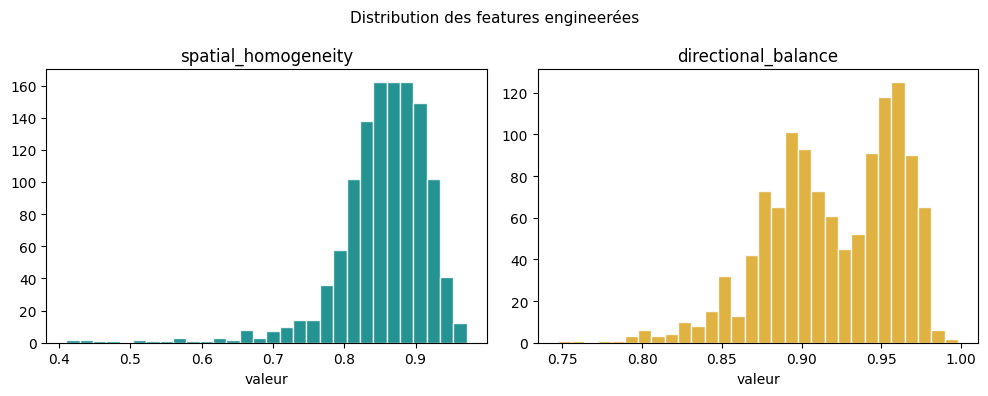

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes,
                           ["spatial_homogeneity", "directional_balance"],
                           ["teal", "goldenrod"]):
    ax.hist(df_clipped[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel("valeur")
fig.suptitle("Distribution des features engineerées", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_engineered_features.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Matrice de features finale

On sélectionne les features pertinentes et on **inverse l'entropie**  
(haute entropie = désordre = mauvaise qualité → on veut que toutes les features pointent dans la même direction).

In [8]:
# Entropie inversée (basée sur le PIRE patch, pas la moyenne)
# → entropy_max capture les artefacts localisés qu'entropy_mean noierait
# ⚠ Anti-leakage : le max est calculé uniquement sur TRAIN
train_mask_clipped = df_clipped["split"] == "train"
entropy_max_train = df_clipped.loc[train_mask_clipped, "entropy_max"].max()
df_clipped["entropy_inv"] = entropy_max_train - df_clipped["entropy_max"]

# Features retenues pour le score composite
# rms_contrast_min : le patch le plus délavé dicte la note du contraste
FEATURE_COLS = [
    "laplacian_var_mean",
    "rms_contrast_min",     # pire patch (au lieu de _mean)
    "entropy_inv",          # inversée (basée sur entropy_max)
    "tenengrad_mean",
    "spatial_homogeneity",
    "directional_balance",
]

X_raw = df_clipped[FEATURE_COLS].values.astype(np.float32)
print(f"Matrice X : {X_raw.shape}  ({len(FEATURE_COLS)} features × {len(df_clipped)} images)")
print(f"Features  : {FEATURE_COLS}")
print(f"entropy_max (ref TRAIN) : {entropy_max_train:.4f}")

Matrice X : (1200, 6)  (6 features × 1200 images)
Features  : ['laplacian_var_mean', 'rms_contrast_min', 'entropy_inv', 'tenengrad_mean', 'spatial_homogeneity', 'directional_balance']
entropy_max (ref TRAIN) : 13.9932


## 6. Méthode A — Score pondéré (physique du signal)

Chaque feature est normalisée à [0, 1] via Min-Max, puis combinée avec les poids définis en section 0.

In [9]:
# ⚠ Anti-leakage : MinMaxScaler fitted sur TRAIN uniquement, puis transform sur tout
train_idx = df_clipped["split"] == "train"
X_train = X_raw[train_idx.values]

scaler_minmax = MinMaxScaler()
scaler_minmax.fit(X_train)                  # fit sur TRAIN seulement
X_norm = scaler_minmax.transform(X_raw)     # transform sur tout le dataset

# Mapping feature → poids (même ordre que FEATURE_COLS)
weight_vector = np.array([
    WEIGHTS["laplacian_var"],
    WEIGHTS["rms_contrast"],
    WEIGHTS["entropy_inv"],
    WEIGHTS["tenengrad"],
    WEIGHTS["spatial_homogeneity"],
    WEIGHTS["directional_balance"],
], dtype=np.float32)

score_A = (X_norm * weight_vector).sum(axis=1)  # (N,) dans [0,1]

df_clipped["score_weighted"] = score_A

print(f"MinMaxScaler fitted sur {int(train_idx.sum())} images TRAIN")
print(f"Score pondéré — min={score_A.min():.4f}  max={score_A.max():.4f}  mean={score_A.mean():.4f}")

MinMaxScaler fitted sur 1000 images TRAIN
Score pondéré — min=0.1311  max=0.8221  mean=0.4514


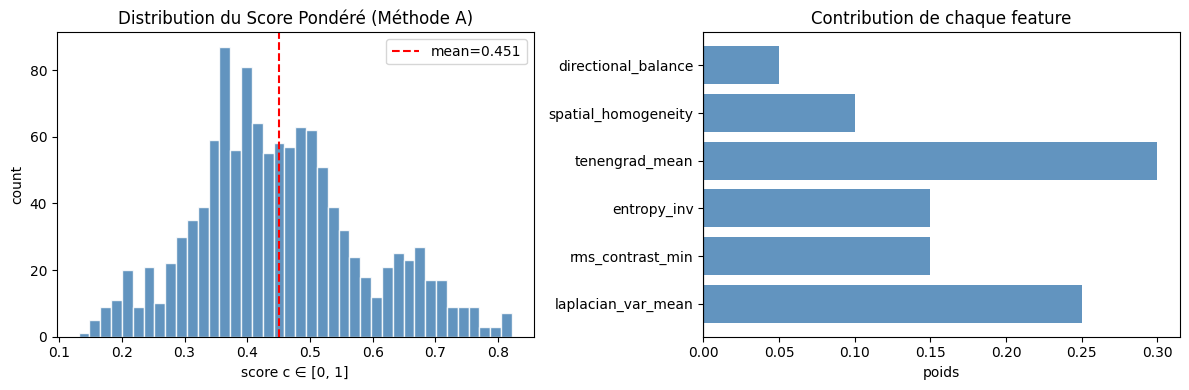

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(score_A, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution du Score Pondéré (Méthode A)")
axes[0].set_xlabel("score c ∈ [0, 1]")
axes[0].set_ylabel("count")
axes[0].axvline(score_A.mean(), color="red", lw=1.5, ls="--", label=f"mean={score_A.mean():.3f}")
axes[0].legend()

# Contribution de chaque feature
axes[1].barh(FEATURE_COLS, weight_vector, color="steelblue", alpha=0.85)
axes[1].set_xlabel("poids")
axes[1].set_title("Contribution de chaque feature")
axes[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_score_weighted.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Méthode B — Premier composant principal (PCA)

La PCA cherche la direction de **variance maximale** dans l'espace des features.  
Si nos métriques sont cohérentes, le PC1 devrait correspondre à l'axe de qualité.

> **Attention au signe :** la PCA ne garantit pas que PC1 > 0 = bonne qualité.  
> On vérifie la corrélation de PC1 avec le Tenengrad et on flip si nécessaire.

In [11]:
# ⚠ Anti-leakage : StandardScaler et PCA fitted sur TRAIN uniquement
scaler_std = StandardScaler()
scaler_std.fit(X_train)                     # fit sur TRAIN seulement
X_std = scaler_std.transform(X_raw)         # transform sur tout le dataset

X_std_train = X_std[train_idx.values]

pca = PCA(n_components=min(6, X_std.shape[1]))
pca.fit(X_std_train)                        # fit sur TRAIN seulement

print(f"StandardScaler + PCA fitted sur {len(X_std_train)} images TRAIN")
print("Variance expliquée par composant :")
for i, r in enumerate(pca.explained_variance_ratio_):
    cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1} : {r*100:5.1f}%   (cumulé : {cumul*100:5.1f}%)")

StandardScaler + PCA fitted sur 1000 images TRAIN
Variance expliquée par composant :
  PC1 :  56.1%   (cumulé :  56.1%)
  PC2 :  22.1%   (cumulé :  78.2%)
  PC3 :  12.0%   (cumulé :  90.2%)
  PC4 :   5.9%   (cumulé :  96.0%)
  PC5 :   2.8%   (cumulé :  98.9%)
  PC6 :   1.1%   (cumulé : 100.0%)


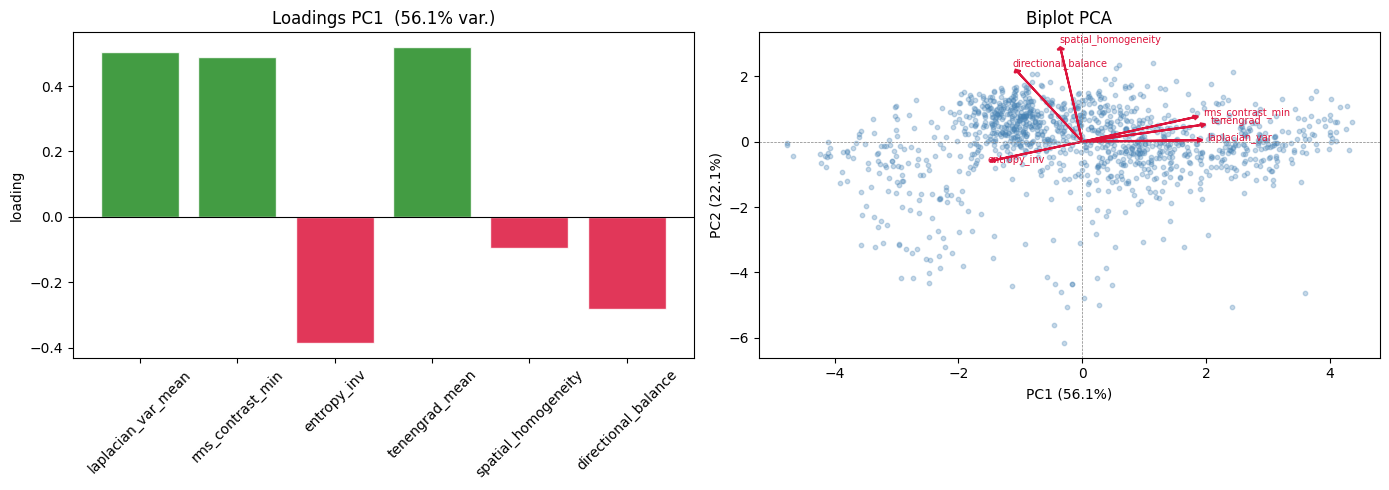

In [12]:
# Biplot : contribution de chaque feature au PC1 et PC2
components = pca.components_  # (n_components, n_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot des loadings PC1
colors_bar = ["forestgreen" if v > 0 else "crimson" for v in components[0]]
axes[0].bar(FEATURE_COLS, components[0], color=colors_bar, edgecolor="white", alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(f"Loadings PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
axes[0].set_ylabel("loading")
axes[0].tick_params(axis="x", rotation=45)

# Biplot PC1 vs PC2
coords = pca.transform(X_std)
axes[1].scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10, color="steelblue")
scale = np.abs(coords[:, :2]).max() * 0.6
for feat, (c1, c2) in zip(FEATURE_COLS, zip(components[0], components[1])):
    axes[1].arrow(0, 0, c1 * scale, c2 * scale,
                  head_width=scale*0.03, head_length=scale*0.02,
                  fc="crimson", ec="crimson", lw=1.5)
    axes[1].text(c1 * scale * 1.08, c2 * scale * 1.08,
                 feat.replace("_mean", ""), fontsize=7, color="crimson")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Biplot PCA")
axes[1].axhline(0, color="grey", lw=0.5, ls="--")
axes[1].axvline(0, color="grey", lw=0.5, ls="--")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_pca_biplot.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
# Extraire PC1 et corriger son signe
pc1_raw = coords[:, 0]

# ⚠ Anti-leakage : corrélation vérifiée sur TRAIN uniquement
pc1_train = pc1_raw[train_idx.values]
corr_with_tenengrad = np.corrcoef(pc1_train, df_clipped.loc[train_idx, "tenengrad_mean"].values)[0, 1]
print(f"Corrélation PC1 ↔ tenengrad_mean (TRAIN) : {corr_with_tenengrad:+.4f}")

if corr_with_tenengrad < 0:
    pc1_raw = -pc1_raw
    print("→ Signe de PC1 inversé pour que score élevé = bonne qualité")
else:
    print("→ Signe de PC1 correct")

# ⚠ Anti-leakage : Min-Max normalisé avec les bornes TRAIN
pc1_train_final = pc1_raw[train_idx.values]
pc1_min, pc1_max = pc1_train_final.min(), pc1_train_final.max()
score_B = (pc1_raw - pc1_min) / (pc1_max - pc1_min + EPS)

df_clipped["score_pca"] = score_B

print(f"Score PCA — min={score_B.min():.4f}  max={score_B.max():.4f}  mean={score_B.mean():.4f}")
print(f"(bornes Min-Max issues de TRAIN : [{pc1_min:.4f}, {pc1_max:.4f}])")

Corrélation PC1 ↔ tenengrad_mean (TRAIN) : +0.9517
→ Signe de PC1 correct
Score PCA — min=-0.0740  max=1.0000  mean=0.4833
(bornes Min-Max issues de TRAIN : [-4.1397, 4.3507])


In [14]:
# ── Validation : comparaison poids manuels vs loadings PCA ────────
# Les loadings absolus de PC1 fournissent une pondération objective.
# On compare avec les poids définis manuellement (Méthode A).

abs_loadings_pc1 = np.abs(components[0])
pca_weights = abs_loadings_pc1 / abs_loadings_pc1.sum()

feature_short = [c.replace("_mean", "").replace("_min", "") for c in FEATURE_COLS]
print("\nComparaison des pondérations :")
print(f"  {'Feature':30s} {'Manuel':>8s}  {'PCA-PC1':>8s}  {'Écart':>8s}")
print("  " + "─" * 58)
for name, fc, pw in zip(feature_short, FEATURE_COLS, pca_weights):
    manual_w = WEIGHTS.get(name, 0.0)
    print(f"  {name:30s} {manual_w:8.3f}  {pw:8.3f}  {abs(manual_w - pw):8.3f}")

corr_manual_pca = np.corrcoef(
    [WEIGHTS.get(n, 0) for n in feature_short],
    pca_weights
)[0, 1]
print(f"\nCorrélation (poids manuels ↔ PCA) : {corr_manual_pca:+.4f}")

if corr_manual_pca > 0.7:
    print("✓ Les poids manuels sont globalement alignés avec PCA — cohérence vérifiée.")
else:
    print("⚠ Les poids manuels divergent de PCA — envisager d'utiliser les loadings PCA.")
    print("  → Pour utiliser les poids PCA : remplacer WEIGHTS par pca_weights dans la cellule 6.")


Comparaison des pondérations :
  Feature                          Manuel   PCA-PC1     Écart
  ──────────────────────────────────────────────────────────
  laplacian_var                     0.250     0.222     0.028
  rms_contrast                      0.150     0.215     0.065
  entropy_inv                       0.150     0.169     0.019
  tenengrad                         0.300     0.228     0.072
  spatial_homogeneity               0.100     0.041     0.059
  directional_balance               0.050     0.124     0.074

Corrélation (poids manuels ↔ PCA) : +0.7435
✓ Les poids manuels sont globalement alignés avec PCA — cohérence vérifiée.


## 8. Comparaison Méthode A vs Méthode B

Corrélation Score A ↔ Score B : 0.9102


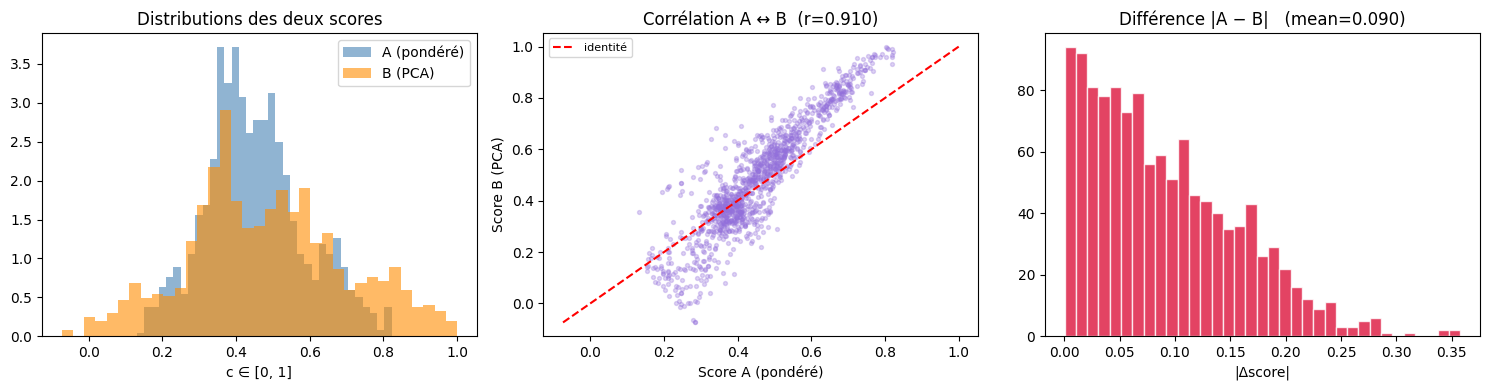

In [15]:
corr_AB = np.corrcoef(score_A, score_B)[0, 1]
print(f"Corrélation Score A ↔ Score B : {corr_AB:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distributions
axes[0].hist(score_A, bins=35, alpha=0.6, color="steelblue", label="A (pondéré)",  density=True)
axes[0].hist(score_B, bins=35, alpha=0.6, color="darkorange", label="B (PCA)",     density=True)
axes[0].set_title("Distributions des deux scores")
axes[0].set_xlabel("c ∈ [0, 1]")
axes[0].legend()

# Scatter A vs B
axes[1].scatter(score_A, score_B, alpha=0.3, s=8, color="mediumpurple")
lo, hi = min(score_A.min(), score_B.min()), max(score_A.max(), score_B.max())
axes[1].plot([lo, hi], [lo, hi], "r--", lw=1.5, label="identité")
axes[1].set_xlabel("Score A (pondéré)")
axes[1].set_ylabel("Score B (PCA)")
axes[1].set_title(f"Corrélation A ↔ B  (r={corr_AB:.3f})")
axes[1].legend(fontsize=8)

# Différence absolue
diff = np.abs(score_A - score_B)
axes[2].hist(diff, bins=35, color="crimson", edgecolor="white", alpha=0.8)
axes[2].set_title(f"Différence |A − B|   (mean={diff.mean():.3f})")
axes[2].set_xlabel("|Δscore|")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_score_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

In [16]:
# Images où les deux méthodes divergent le plus → cas ambigus
df_clipped["score_disagreement"] = diff
top_disagreement = df_clipped.nlargest(5, "score_disagreement")[["image_id", "score_weighted", "score_pca", "score_disagreement"]]
print("Images les plus ambiguës (désaccord A vs B) :")
print(top_disagreement.to_string(index=False))

Images les plus ambiguës (désaccord A vs B) :
 image_id  score_weighted  score_pca  score_disagreement
      145        0.283620  -0.074011            0.357631
      179        0.282902  -0.073367            0.356269
       77        0.279471  -0.062689            0.342159
      871        0.340882   0.681680            0.340799
      853        0.328012   0.640847            0.312835


## 9. Enrichissement avec les features ResNet-18

Si les features ResNet-18 ont été extraites dans le Notebook 2, on peut calculer un score PCA dans cet espace  
et le **moyenner** avec le score B pour un biais inductif plus riche.

**Activé automatiquement si `APPROACH = "C"` dans `pipeline_config.py`.**

In [17]:
if USE_RESNET:
    if not (RESNET_NPY.exists() and RESNET_IDS_CSV.exists()):
        raise FileNotFoundError(
            f"Approche {APPROACH} requiert les features ResNet-18 mais les fichiers sont absents.\n"
            f"Relancez d'abord le Notebook 2 avec APPROACH = '{APPROACH}'."
        )

    feat_arr  = np.load(RESNET_NPY)                                  # (N_feat, 512)
    feat_ids  = pd.read_csv(RESNET_IDS_CSV)["image_id"].tolist()     # N_feat

    # ⚠ Anti-leakage : identifier les indices TRAIN dans feat_ids
    train_image_ids = set(df_clipped.loc[train_idx, "image_id"])
    feat_train_mask = np.array([iid in train_image_ids for iid in feat_ids])
    feat_arr_train  = feat_arr[feat_train_mask]

    # Réduire 512 → 1 dimension (PC1 dans l'espace ResNet)
    # ⚠ Anti-leakage : StandardScaler et PCA fitted sur TRAIN uniquement
    scaler_rn = StandardScaler()
    scaler_rn.fit(feat_arr_train)
    feat_arr_std = scaler_rn.transform(feat_arr)

    pca_rn = PCA(n_components=1)
    pca_rn.fit(feat_arr_std[feat_train_mask])
    pc1_rn = pca_rn.transform(feat_arr_std).squeeze()

    # Corriger le signe : corrélation avec tenengrad (TRAIN uniquement)
    feat_ids_to_score = dict(zip(feat_ids, pc1_rn))
    rn_scores = np.array([feat_ids_to_score.get(iid, np.nan) for iid in df_clipped["image_id"]])

    valid_mask = ~np.isnan(rn_scores)
    valid_train_mask = valid_mask & train_idx.values
    corr_rn = np.corrcoef(rn_scores[valid_train_mask],
                          df_clipped["tenengrad_mean"].values[valid_train_mask])[0, 1]
    if corr_rn < 0:
        rn_scores = -rn_scores

    # ⚠ Anti-leakage : normalisation [0, 1] avec bornes TRAIN
    rn_train_scores = rn_scores[valid_train_mask]
    rn_min, rn_max = rn_train_scores.min(), rn_train_scores.max()
    score_RN = (rn_scores - rn_min) / (rn_max - rn_min + EPS)
    df_clipped["score_resnet"] = score_RN

    print(f"Score ResNet — varexp={pca_rn.explained_variance_ratio_[0]*100:.1f}%  "
          f"corr_tenengrad(TRAIN)={corr_rn:+.4f}")
    print(f"StandardScaler + PCA fitted sur {int(feat_train_mask.sum())} images TRAIN")

    # Score hybride = moyenne des 3 scores
    df_clipped["score_hybrid"] = np.nanmean(
        np.stack([score_A, score_B, score_RN], axis=1), axis=1
    )
    print(f"Score hybride (A+B+ResNet) — mean={df_clipped['score_hybrid'].mean():.4f}")
else:
    print(f"Section ResNet ignorée (approche {APPROACH})")
    df_clipped["score_resnet"] = np.nan
    df_clipped["score_hybrid"] = np.nan

Section ResNet ignorée (approche B)


## 8. Sélection du score final selon l'approche

Le score utilisé comme `quality_score` est déterminé par `APPROACH` dans `pipeline_config.py`.

In [18]:
# Sélection du score basée sur APPROACH (défini dans pipeline_config.py)
FINAL_SCORE_COL = get_score_column()

# Vérifier que la colonne existe
if FINAL_SCORE_COL not in df_clipped.columns:
    available = [c for c in df_clipped.columns if c.startswith("score_")]
    raise ValueError(
        f"Approche '{APPROACH}' requiert la colonne '{FINAL_SCORE_COL}' "
        f"mais elle n'existe pas.\nColonnes disponibles : {available}"
    )

# Vérifier que les valeurs ne sont pas toutes NaN (cas de score_hybrid sans ResNet)
if df_clipped[FINAL_SCORE_COL].isna().all():
    raise ValueError(
        f"La colonne '{FINAL_SCORE_COL}' (approche {APPROACH}) ne contient que des NaN. "
        f"Vérifiez que les données nécessaires sont disponibles."
    )

df_clipped["quality_score"] = df_clipped[FINAL_SCORE_COL]

approach_cfg = get_approach_config()
print(f"Approche sélectionnée : {APPROACH} — {approach_cfg['name']}")
print(f"Colonne utilisée     : {FINAL_SCORE_COL}")
print(f"Score — min={df_clipped['quality_score'].min():.4f}  "
      f"max={df_clipped['quality_score'].max():.4f}  "
      f"mean={df_clipped['quality_score'].mean():.4f}")

Approche sélectionnée : B — PCA (PC1)
Colonne utilisée     : score_pca
Score — min=-0.0740  max=1.0000  mean=0.4833


## 11. Validation visuelle — galerie triée par score

C'est la figure de validation clé : elle prouve que notre score est cohérent avec la qualité visuelle.

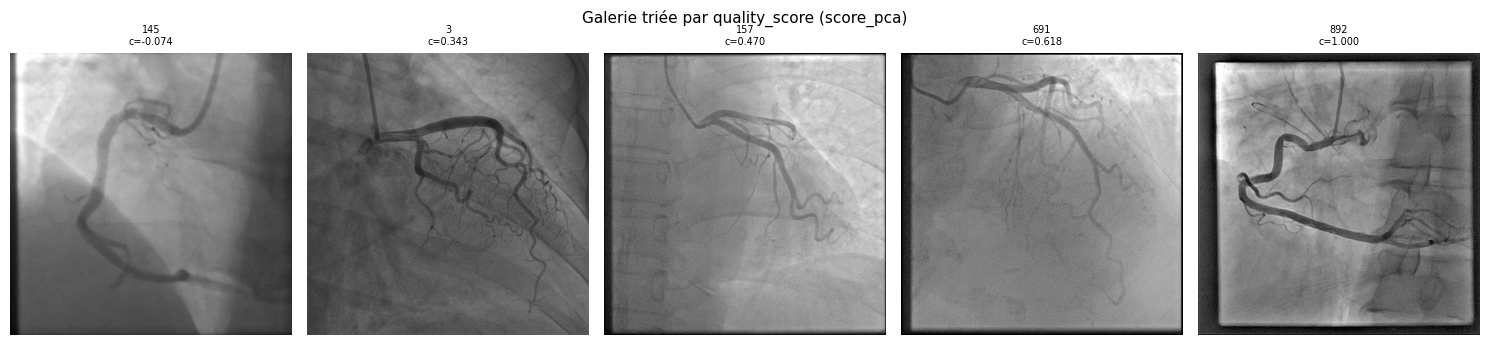

In [19]:
def load_gray(path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0


df_sorted = df_clipped.sort_values("quality_score").reset_index(drop=True)

# Sélectionner 5 images dans chaque quintile
N_COL  = 5
n_imgs = len(df_sorted)
quintile_indices = np.linspace(0, n_imgs - 1, N_COL, dtype=int)

fig, axes = plt.subplots(1, N_COL, figsize=(3 * N_COL, 3.5))

for col, idx in enumerate(quintile_indices):
    row_data = df_sorted.iloc[idx]
    try:
        img = load_gray(row_data["path"])
    except Exception:
        img = np.zeros((64, 64))
    axes[col].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(
        f"{str(row_data['image_id'])[:12]}\nc={row_data['quality_score']:.3f}",
        fontsize=7
    )
    axes[col].axis("off")

fig.suptitle(f"Galerie triée par quality_score ({FINAL_SCORE_COL})", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_gallery_sorted_by_score.png", dpi=120, bbox_inches="tight")
plt.show()

In [20]:
# Validation quantitative : corrélation du score final avec chaque métrique
print("Corrélation du score final avec les métriques brutes :")
for col in MEAN_COLS + ["spatial_homogeneity", "directional_balance"]:
    r = np.corrcoef(df_clipped["quality_score"].values,
                    df_clipped[col].values)[0, 1]
    bar = "▓" * int(abs(r) * 20)
    sign = "+" if r > 0 else "-"
    print(f"  {col:30s}  r={r:+.4f}  {sign}{bar}")

Corrélation du score final avec les métriques brutes :
  laplacian_var_mean              r=+0.9177  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  rms_contrast_mean               r=+0.9198  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  entropy_mean                    r=-0.0203  -
  tenengrad_mean                  r=+0.9520  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_H_mean                      r=+0.9306  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_V_mean                      r=+0.9366  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D1_mean                     r=+0.9581  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  ten_D2_mean                     r=+0.9532  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  spatial_homogeneity             r=-0.1407  -▓▓
  directional_balance             r=-0.4736  -▓▓▓▓▓▓▓▓▓


## 12. Seuillage en labels catégoriels

On divise le score en **3 classes** (tertiles) pour :
- La visualisation dans les notebooks suivants
- L'évaluation de robustesse du Notebook 5 (test sur les images "bad")

| Label | Tertile | Signification |
|---|---|---|
| `bad` | [0, 33%[ | Images avec artefacts sévères |
| `medium` | [33%, 67%[ | Qualité acceptable |
| `good` | [67%, 100%] | Images cliniquement exploitables |

In [21]:
# ⚠ Anti-leakage : seuils de tertiles calculés sur TRAIN uniquement
train_scores = df_clipped.loc[train_idx, "quality_score"]
t33 = train_scores.quantile(1/3)
t67 = train_scores.quantile(2/3)

def assign_label(score: float) -> str:
    if score < t33:
        return "bad"
    elif score < t67:
        return "medium"
    return "good"

df_clipped["quality_label"] = df_clipped["quality_score"].apply(assign_label)

print(f"Seuils (calculés sur TRAIN) : bad < {t33:.4f} ≤ medium < {t67:.4f} ≤ good")
print("\nDistribution des labels (tout le dataset) :")
print(df_clipped["quality_label"].value_counts().to_string())
print("\nDistribution par split :")
print(df_clipped.groupby("split")["quality_label"].value_counts().unstack(fill_value=0))

Seuils (calculés sur TRAIN) : bad < 0.3662 ≤ medium < 0.5692 ≤ good

Distribution des labels (tout le dataset) :
quality_label
medium    423
good      401
bad       376

Distribution par split :
quality_label  bad  good  medium
split                           
train          333   334     333
val             43    67      90


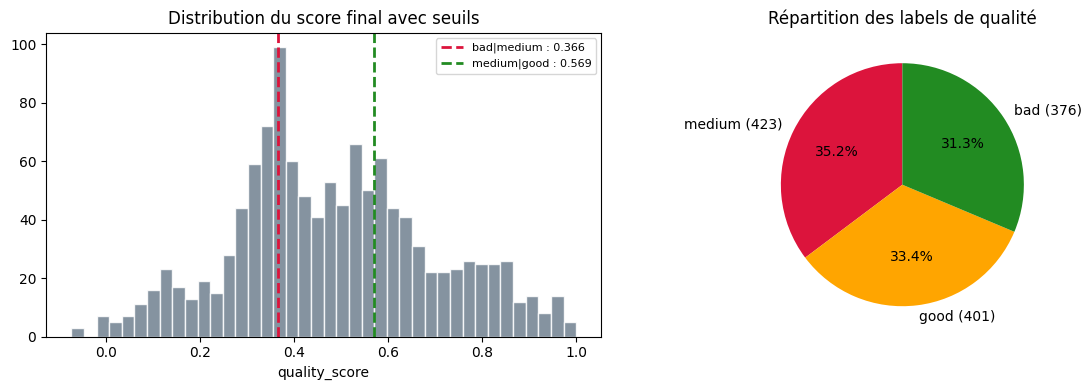

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution du score avec seuils
axes[0].hist(df_clipped["quality_score"], bins=40, color="slategray", edgecolor="white", alpha=0.85)
axes[0].axvline(t33, color="crimson",     lw=2, ls="--", label=f"bad|medium : {t33:.3f}")
axes[0].axvline(t67, color="forestgreen", lw=2, ls="--", label=f"medium|good : {t67:.3f}")
axes[0].set_title("Distribution du score final avec seuils")
axes[0].set_xlabel("quality_score")
axes[0].legend(fontsize=8)

# Camembert des labels
counts = df_clipped["quality_label"].value_counts()
axes[1].pie(
    counts.values,
    labels=[f"{l} ({n})" for l, n in counts.items()],
    colors=["crimson", "orange", "forestgreen"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Répartition des labels de qualité")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_label_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

## 13. Galerie good / bad / medium (9 exemples)

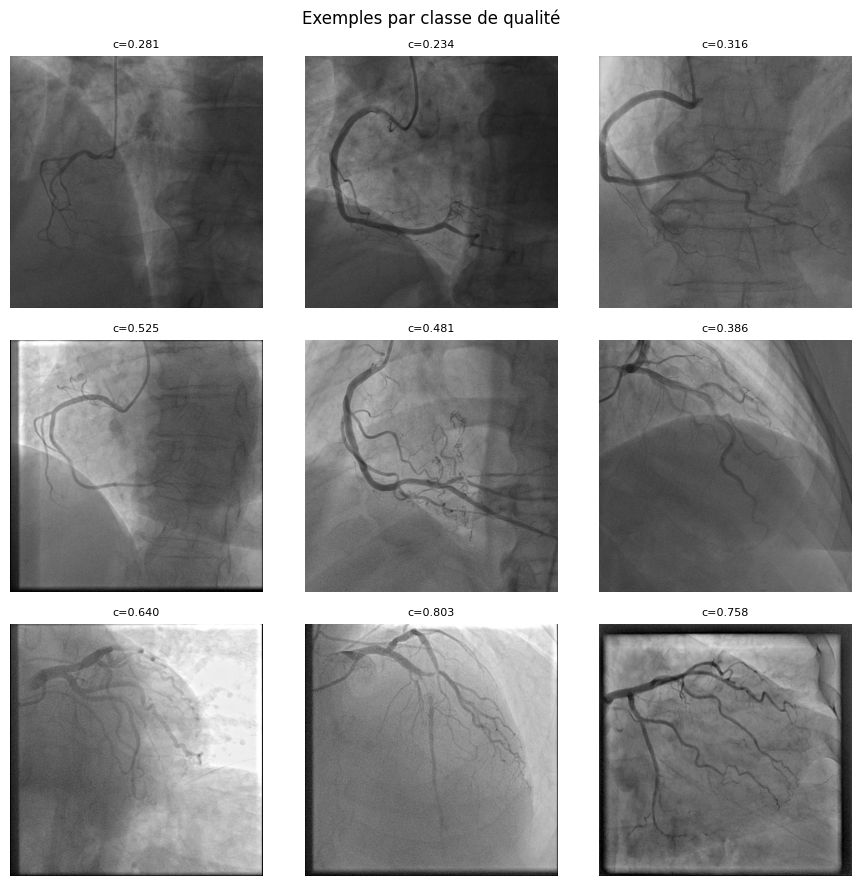

In [23]:
import random
random.seed(0)

N_PER_CLASS = 3
label_order = ["bad", "medium", "good"]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

fig, axes = plt.subplots(len(label_order), N_PER_CLASS, figsize=(3 * N_PER_CLASS, 3 * len(label_order)))

for row, label in enumerate(label_order):
    subset = df_clipped[df_clipped["quality_label"] == label]
    sample = subset.sample(min(N_PER_CLASS, len(subset)), random_state=row)
    for col, (_, r) in enumerate(sample.iterrows()):
        ax = axes[row, col]
        try:
            img = load_gray(r["path"])
        except Exception:
            img = np.zeros((64, 64))
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"c={r['quality_score']:.3f}", fontsize=8)
        if col == 0:
            ax.set_ylabel(label.upper(), color=label_colors[label], fontsize=10, fontweight="bold")
        ax.axis("off")

fig.suptitle("Exemples par classe de qualité", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_examples_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

## 14. Export — `labels_quality.csv`

Ce fichier est le **pont entre ce travail et le Notebook 4** (modification de l'architecture MedVAE).

In [24]:
export_cols = [
    "image_id",
    "path",
    "split",
    "quality_score",
    "quality_label",
    "score_weighted",
    "score_pca",
]
if USE_RESNET:
    export_cols += ["score_resnet", "score_hybrid"]

df_export = df_clipped[export_cols].copy()
df_export.to_csv(OUT_LABELS_CSV, index=False)

print(f"Sauvegardé → {OUT_LABELS_CSV}")
print(f"Lignes     : {len(df_export)}  (train={int((df_export['split']=='train').sum())}, val={int((df_export['split']=='val').sum())})")
print(f"Colonnes   : {export_cols}")
df_export.head(5)

Sauvegardé → outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv
Lignes     : 1200  (train=1000, val=200)
Colonnes   : ['image_id', 'path', 'split', 'quality_score', 'quality_label', 'score_weighted', 'score_pca']


,image_id,path,split,quality_score,quality_label,score_weighted,score_pca
0,1,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.477749,medium,0.462468,0.477749
1,10,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.333257,bad,0.474949,0.333257
2,100,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.518073,medium,0.468219,0.518073
3,1000,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.795698,good,0.675590,0.795698
4,101,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.522800,medium,0.501608,0.522800


In [25]:
# Vérification finale : statistiques par label
print("Statistiques du quality_score par label :")
print(df_export.groupby("quality_label")["quality_score"].describe().round(4).to_string())

Statistiques du quality_score par label :
               count    mean     std     min     25%     50%     75%     max
quality_label                                                               
bad            376.0  0.2519  0.1038 -0.0740  0.1760  0.2879  0.3346  0.3654
good           401.0  0.7234  0.1161  0.5692  0.6183  0.7038  0.8167  1.0000
medium         423.0  0.4615  0.0625  0.3662  0.4018  0.4630  0.5182  0.5691


## Résumé du Notebook 3

| Étape | Résultat |
|---|---|
| Feature engineering | `spatial_homogeneity` + `directional_balance` |
| Méthode A | Score pondéré physique ∈ [0, 1] |
| Méthode B | PC1 normalisé (objectif, data-driven) |
| Méthode C | Hybride A+B+ResNet-18 (si approche C) |
| Score final retenu | Selon `APPROACH` dans `pipeline_config.py` |
| Labels catégoriels | `bad` / `medium` / `good` (tertiles) |
| Export | `outputs/labels_quality.csv` |

**Prochain notebook :** `04_MedVAE_Architecture_Mod.ipynb` —  
Modifier le DataLoader et l'encodeur/décodeur MedVAE pour conditionner la génération sur `quality_score`.